In [86]:
import os
from functools import reduce
import json
import numpy as np
import matplotlib.pyplot as plt

In [87]:
def get_files_in_directory(directory_path):
    files = []
    for entry in os.listdir(directory_path):
        full_path = os.path.join(directory_path, entry)
        if os.path.isfile(full_path):
            files.append(full_path)
    return files

In [136]:
def apply_median(in_result: dict):
    return {
        int(num.split('_')[-1]): {
            (f"{generic_impl_key}({sub_result_key})" if generic_impl_key != sub_result_key else generic_impl_key): None if len(sub_results) == 0 else np.median(sub_results)
            for generic_impl_key, generic_impl_result in per_num.items()
            for sub_result_key, sub_results in generic_impl_result.items()
        }
        for num, per_num in in_result.items()
    }

def _sum(dict_1, dict_2):
    assert set(dict_1.keys()) == set(dict_2.keys())
    return {
        key: None if dict_1[key] is None or dict_2[key] is None else dict_1[key] + dict_2[key]
        for key in dict_1
    }
def augment_result(raw_result: dict[str, float]):
    extras = {
        'traceprov(base + infer)': _sum(raw_result['traceprov(base)'], raw_result['traceprov(infer)']),
        'traceprov(base + infer + materialize)': _sum(raw_result['traceprov(base)'], raw_result['traceprov(materialize)'])
    }
    assert 'traceprov(materialize)' in raw_result
    assert 'traceprov(infer)' in raw_result
    keys_to_remove = ['traceprov(materialize)', 'traceprov(infer)']
    removed = {
        key: value for key, value in raw_result.items() if key not in keys_to_remove
    }
    return {**removed, **extras}


def plot_results(db_results, plots):
    all_results = {}
    # queries_sorted_order = ["03", "04", "05", "06", "07"]
    queries_sorted_order = ["03", "04", "05", "06"]
    sorted_labels = [
        "base",
        "gprom_join(base)",
        "gprom_join(materialize)",
        "gprom_window(base)",
        "gprom_window(materialize)",
        "traceprov(base)",
        "traceprov(base + infer)",
        "traceprov(base + infer + materialize)"
    ]
    colors = ["tab:blue", "tab:orange", "tab:green", "tab:red", "tab:purple", "tab:brown", "tab:pink", "tab:gray"]
    queries_axis = np.arange(len(queries_sorted_order))
    for file in db_results:
        with open(file) as f:
            result_json: dict = json.loads(f.read())
            assert len(result_json) == 1
            db_result = apply_median(list(result_json.values())[0])

        parsed_query_num = file.split('_')[-1].split('.')[0]
        assert parsed_query_num not in all_results
        all_results[parsed_query_num] = db_result
    
    # Now, need to flatten the results out
    def _reduce(previous, current):
        key, per_key = current
        new_result = {
            per_num: {**previous.get(per_num, {}), key: opaque_result}
            for per_num, opaque_result in per_key.items()
        }
        return {
            **previous,
            **new_result
        }

    all_results_flattened = reduce(_reduce, all_results.items(), {})
    all_results_flattened_per_impl = {num: reduce(_reduce, num_result.items(), {}) for num, num_result in all_results_flattened.items()}
    all_results_nones_eliminated = {
        num: augment_result({
            impl: result
            for impl, result in num_result.items()
            if any(_result is not None for _result in result.values())
        })
        for num, num_result in all_results_flattened_per_impl.items()
    }
    # # print(json.dumps(all_results_flattened_per_impl, indent=4))
    # print(json.dumps(all_results_nones_eliminated, indent=4))
    all_results_sorted = sorted(([
        (num, sorted([(impl, sorted([(query, query_result) for query, query_result in impl_result.items()], key=lambda x: queries_sorted_order.index(x[0]))) for (impl, impl_result) in result.items()], key=lambda x: sorted_labels.index(x[0])))
        for num, result in all_results_nones_eliminated.items()
    ]), key=lambda x: x[0])

    width = 0.1
    for outer_id, (num, num_result) in enumerate(all_results_sorted):
        ax = plots[outer_id]
        for idx, (impl, impl_results) in enumerate(num_result):
            offset = width * idx
            timings = [res[1] or 0 for res in impl_results]
            rects = ax.bar(queries_axis + offset, timings, width, label=impl, color=colors[idx])
            # ax.bar_label(rects, padding=3, fontsize=6, rotation=30, fmt='%.2f')
        ax.set_xticks(queries_axis + 4.5*width, queries_sorted_order)
        # ax.set_ylabel("Execution Time (s)")
        # ax.set_xlabel("Query")
        # ax.set_title(f"Execution Time: {num}")
        # plt.legend(loc='best')
        # # fig.legend(loc='outside right center', ncols=1, bbox_to_anchor=(1.3, 0.5))
        # plt.grid(axis="x", linestyle="--", alpha=0.7)
        # plt.grid(axis="y", linestyle="--", alpha=0.7)
        # plt.tight_layout()
        ax.set_yscale('log', base=10)
        # plt.savefig(f'{out_dir}/execution_time_{scale}.png', bbox_inches='tight')
    # print(all_results_sorted)
    # print(all_results)
    

10
100
1000


/tmp/ipykernel_8899/4166443172.py:28: UserWarning: Tight layout not applied. tight_layout cannot make axes width small enough to accommodate all axes decorations
  plt.tight_layout()


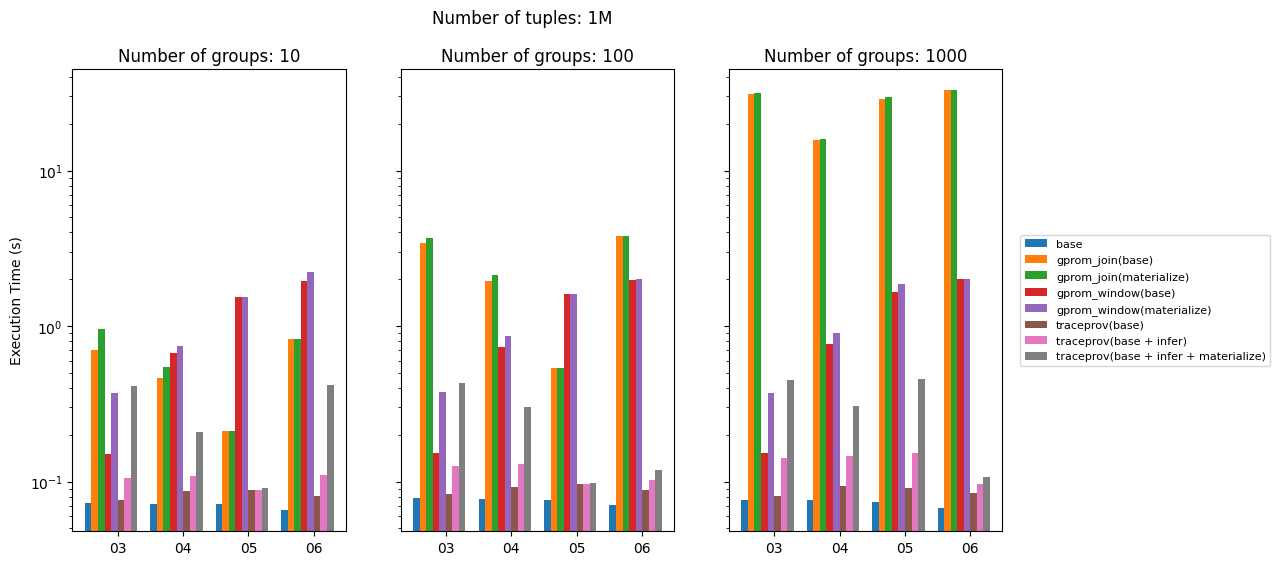

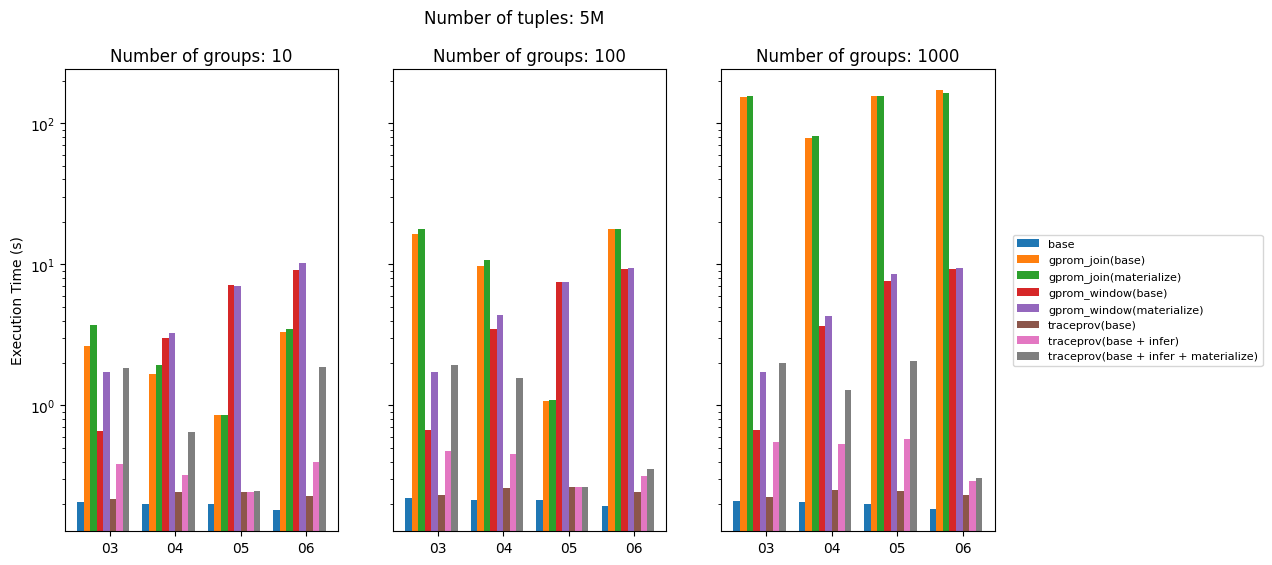

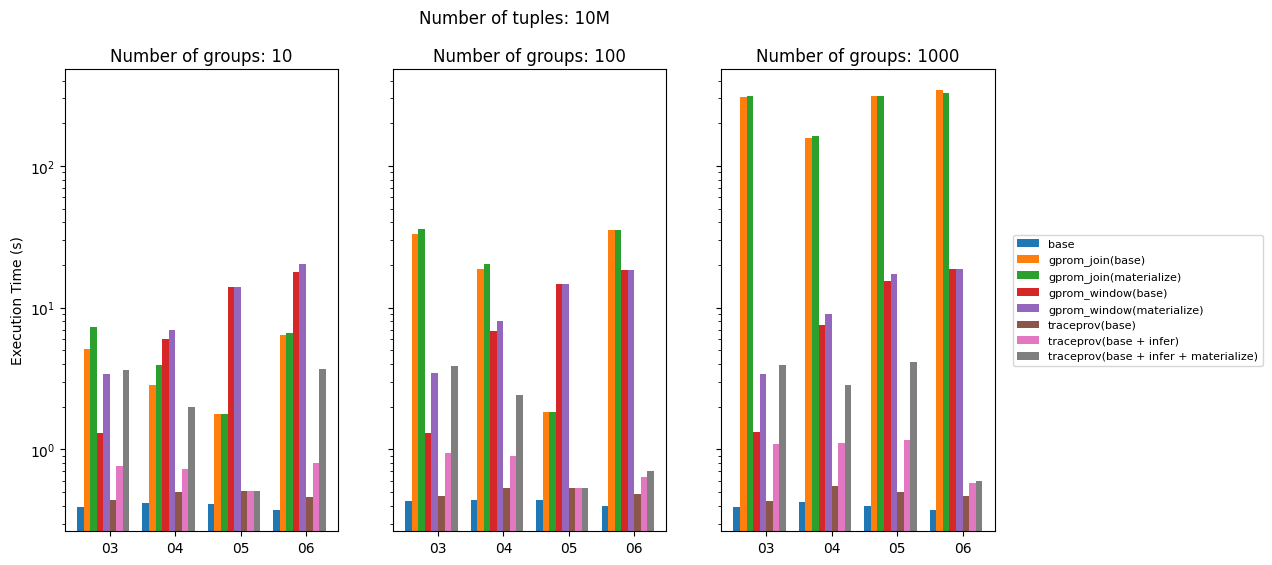

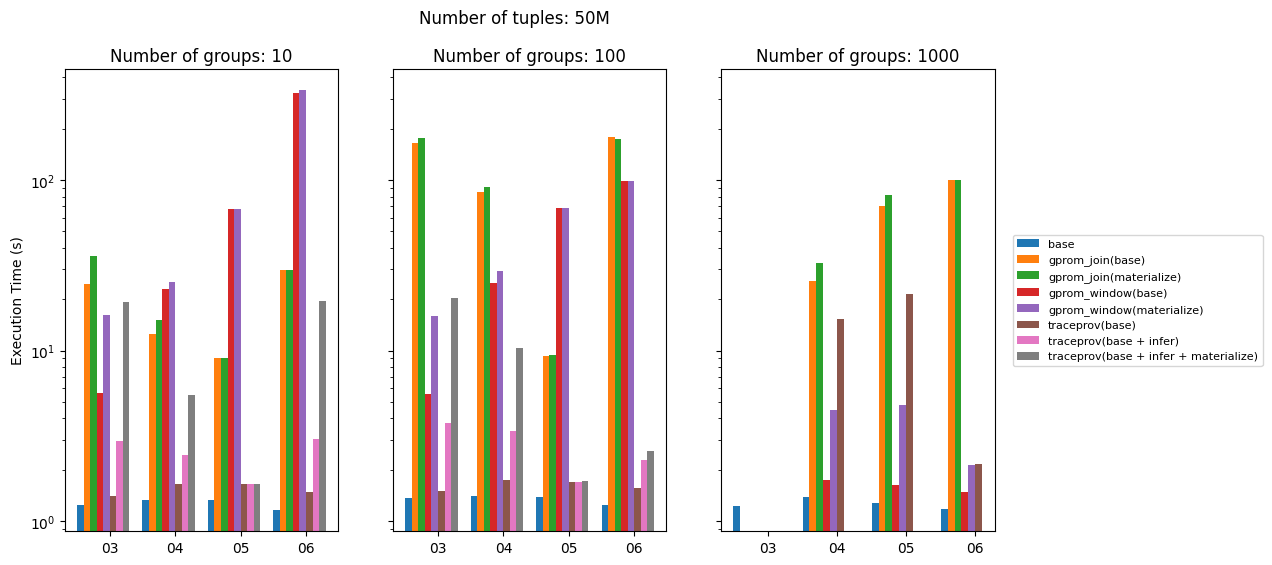

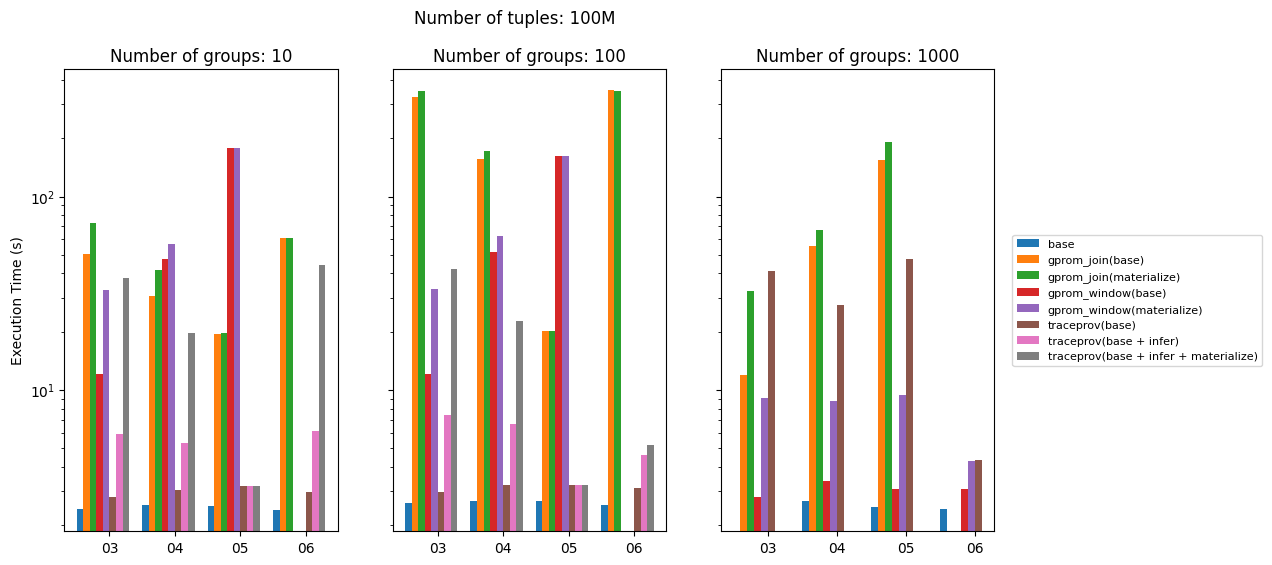

In [143]:
def plot_results_driver(results_dir='./'):
    num_tuples = [
        '1M', "5M", "10M", "50M", "100M"
    ]
    files = get_files_in_directory(results_dir)
    def _reduce(previous: dict, current: str):
        key = int('_'.join(current.split('_')[-2:-1]))
        return {**previous, key: [*previous.get(key, []), current]}
    grouped_per_db = reduce(_reduce, files, {})

    all_figures = []
    for i in range(5):
        figure, axs = plt.subplots(1, 3, sharey=True)
        figure.set_size_inches(12, 6)
        all_figures.append((figure, axs))

    for _id, key in enumerate(sorted(grouped_per_db.keys())):
        print(key)
        plots = [axis[_id] for _, axis in all_figures]
        plot_results(grouped_per_db[key], plots)
        for (_, axis) in all_figures:
            axis[_id].set_title(f"Number of groups: {key}")
    
    for (fig, axis), num_tuple in zip(all_figures, num_tuples):
        axis[0].legend(loc='center right', prop=dict(size=8), bbox_to_anchor=(4.4, 0.5))
        fig.suptitle(f"Number of tuples: {num_tuple}")
        axis[0].set_ylabel("Execution Time (s)")
    plt.tight_layout()

plot_results_driver('results_2025_09_25')